In [20]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import os
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

In [2]:
# Output File
if not os.path.exists('output'):
    os.makedirs('output')

In [3]:
# Graphics Settings
sns.set_theme(style="darkgrid", palette='viridis')           
plt.rcParams['figure.figsize'] = (10, 5)  
plt.rcParams['font.size'] = 10

In [4]:
# Data Preprocessing
customer_data = pd.read_csv('data/shopping-data.csv')

In [5]:
# Data Exploration
print(customer_data.head())

   CustomerID  Annual Income (k$)  Spending Score (1-100)
0           1                  15                      39
1           2                  15                      81
2           3                  16                       6
3           4                  16                      77
4           5                  17                      40


In [6]:
# delete customerID
data = customer_data.iloc[:, 1:3].values

# Initialization of the model
kmeans = KMeans(n_clusters=5)

In [7]:
# fitting the model
kmeans.fit(data)

print('='*100)
# Centers of the clusters displayed
print('Centers of the clusters displayed:\n',kmeans.cluster_centers_)

print('='*100)
# The labels of each point 
print('The labels of each point:\n',kmeans.labels_)

Centers of the clusters displayed:
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [26.30434783 20.91304348]
 [25.72727273 79.36363636]
 [88.2        17.11428571]]
The labels of each point:
 [2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 0 2 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 4 1 0 1 4 1 4 1 0 1 4 1 4 1 4 1 4 1 0 1 4 1 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4
 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1]



Fig 1: saved: output/01_Clusters.png


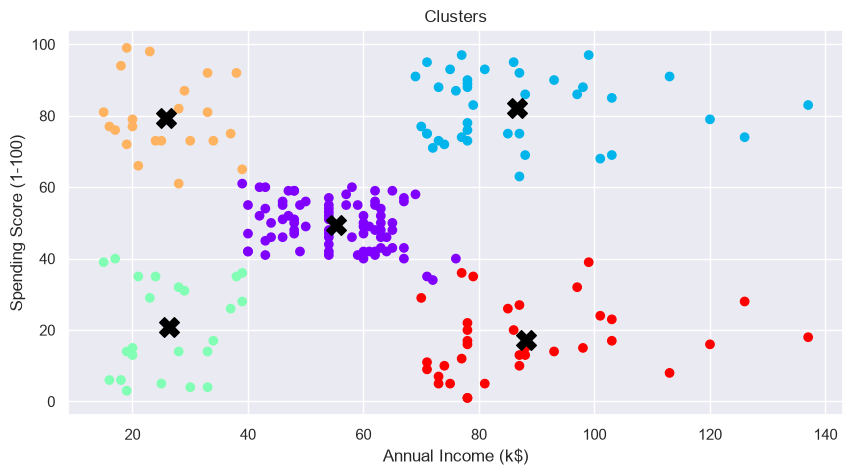

In [8]:
# Drawing the clusters
plt.scatter(data[:,0],data[:,1], c=kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:,0] ,kmeans.cluster_centers_[:,1], color='black', marker='X', s=200)

plt.title("Clusters")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.savefig('output/01_Clusters.png', dpi=300, bbox_inches='tight')
print("\nFig 1: saved: output/01_Clusters.png")

plt.show()

In [9]:
# fitting the model
cluster_labels = kmeans.fit_predict(data)


print('='*100)

# Sample size
range_n_clusters = [2, 3, 4, 5, 6, 7]
print('silhouette Average:\n')

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters)
    cluster_labels = clusterer.fit_predict(data)

    # silhouette coefficient
    silhouette_avg = silhouette_score(data, cluster_labels)
    print(
        "For n =",
        n_clusters,
        "silhouette_score is :",
        silhouette_avg,
    )

print('='*100)

silhouette Average:

For n = 2 silhouette_score is : 0.2968969162503008
For n = 3 silhouette_score is : 0.3448462529049617
For n = 4 silhouette_score is : 0.4931963109249047
For n = 5 silhouette_score is : 0.553931997444648
For n = 6 silhouette_score is : 0.5375812731362782
For n = 7 silhouette_score is : 0.5270287298101395


Fig 2: saved: output/02_Dendrogram.png


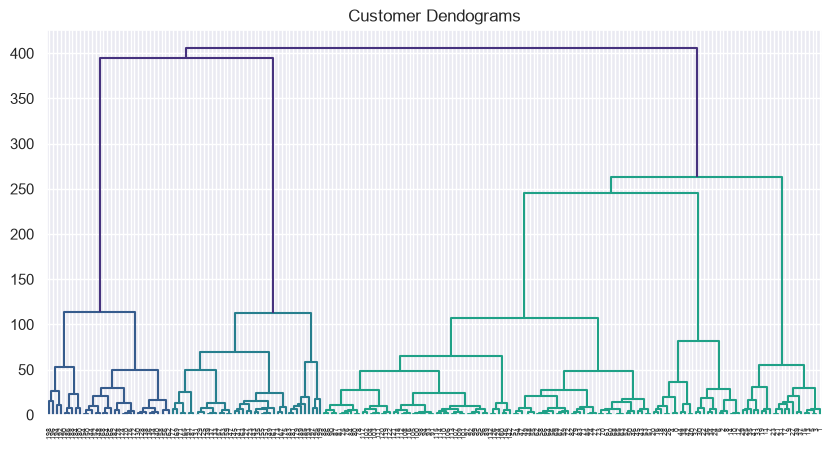

In [10]:
# Ward Linkage
linked = linkage(data, 'ward')

# dendrogram
threshold = 0.7*np.max(linked[:,2])
dendrogram(linked,color_threshold=threshold,
            orientation='top',
            distance_sort='descending',
            show_leaf_counts=True)
# Drawing the dendrogram
plt.title("Customer Dendograms")
plt.savefig('output/02_Dendrogram.png', dpi=300, bbox_inches='tight')
print("Fig 2: saved: output/02_Dendrogram.png")

plt.show()

In [11]:
# fitting the model
cluster = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
cluster.fit_predict(data)

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

Fig 3: saved: output/03_scatter.png


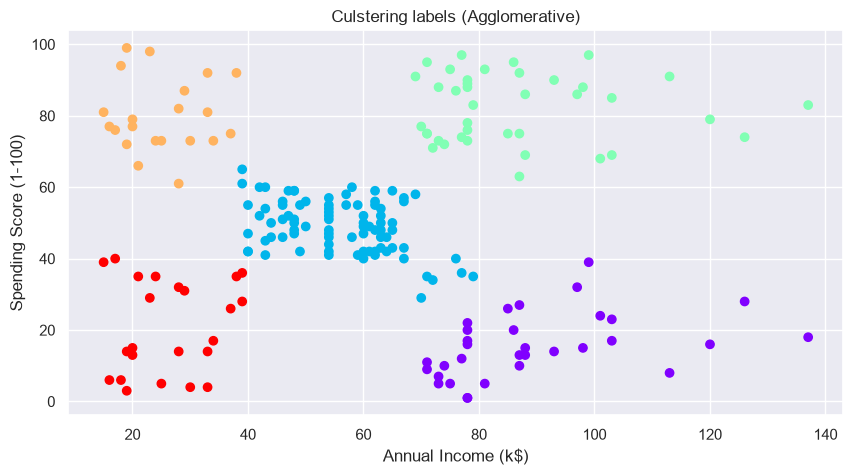

In [12]:
# Drawing the clusters
plt.scatter(data[:,0], data[:,1], c=cluster.labels_, cmap='rainbow')

plt.title("Culstering labels (Agglomerative)")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.savefig('output/03_scatter.png', dpi=300, bbox_inches='tight')
print("Fig 3: saved: output/03_scatter.png")

plt.show()

In [13]:
# توحيد البيانات للحصول على مقاييس دقيقة
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [14]:
# 1. مقاييس K‑means (k=5) 
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(data_scaled)

sil = silhouette_score(data_scaled, labels_kmeans)
db  = davies_bouldin_score(data_scaled, labels_kmeans)
ch  = calinski_harabasz_score(data_scaled, labels_kmeans)

print("\n=== Scales K-means (k=5) ========")
print(f"Silhouette          : {sil:.4f}")
print(f"Davies-Bouldin      : {db:.4f}")
print(f"Calinski-Harabasz   : {ch:.4f}")
print('='*35)


=== Scales K-means (k=5) ========
Silhouette          : 0.5547
Davies-Bouldin      : 0.5722
Calinski-Harabasz   : 248.6493


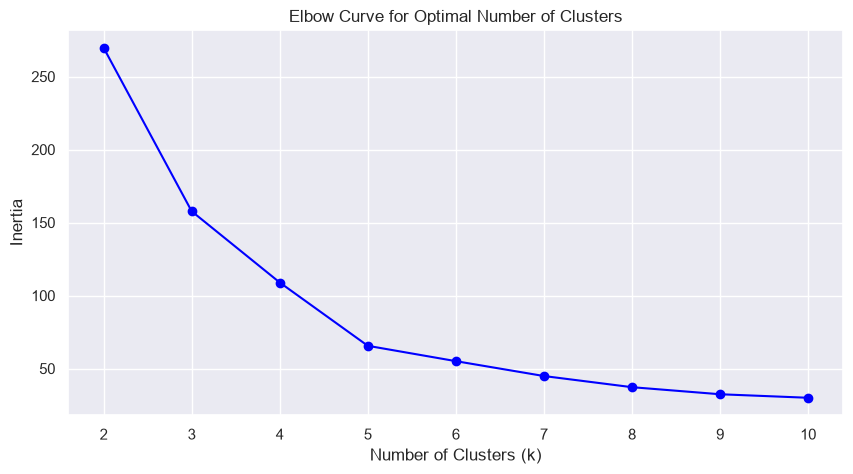


Fig 4: saved: output/04_Elbow.png


In [15]:
# 2. منحنى الكوع (Elbow) 
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for Optimal Number of Clusters')
plt.savefig('output/04_Elbow.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nFig 4: saved: output/04_Elbow.png")

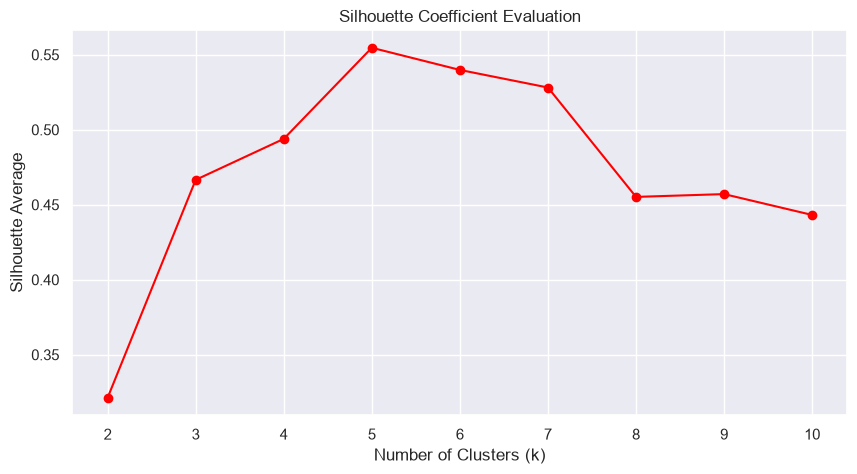

Fig 5: saved: output/05_Silhouette_vs_k.png


In [16]:
# 3. معامل Silhouette مقابل عدد التجمعات 
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_scaled)
    sil_scores.append(silhouette_score(data_scaled, labels))

plt.figure()
plt.plot(k_range, sil_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Average')
plt.title('Silhouette Coefficient Evaluation')
plt.savefig('output/05_Silhouette_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 5: saved: output/05_Silhouette_vs_k.png")

In [17]:
# 4. تقييم التجميع الهرمي (Agglomerative)
agg = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
labels_agg = agg.fit_predict(data_scaled)

sil_agg = silhouette_score(data_scaled, labels_agg)
db_agg  = davies_bouldin_score(data_scaled, labels_agg)
ch_agg  = calinski_harabasz_score(data_scaled, labels_agg)

print("\n=== Agglomerative (k=5) ==========")
print(f"Silhouette          : {sil_agg:.4f}")
print(f"Davies-Bouldin      : {db_agg:.4f}")
print(f"Calinski-Harabasz   : {ch_agg:.4f}")
print('='*35)


=== Agglomerative (k=5) ==========
Silhouette          : 0.5538
Davies-Bouldin      : 0.5779
Calinski-Harabasz   : 244.4103


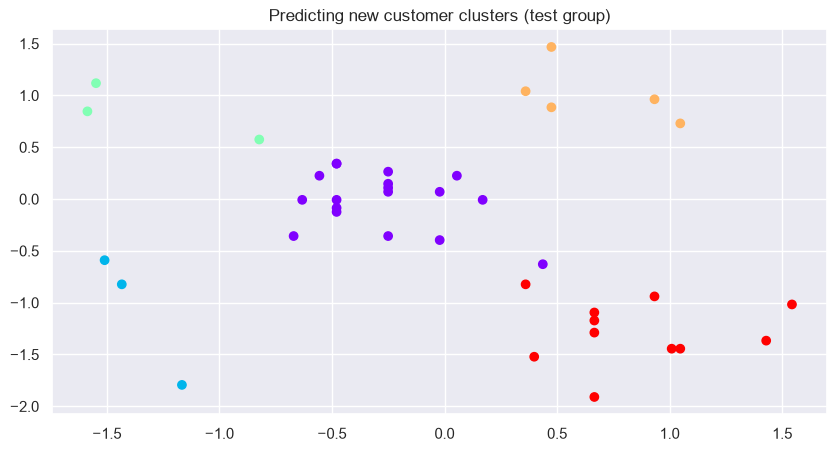

Fig 7: saved: output/07_TestSet_Predictions.png


In [22]:
# استخدام 80% تدريب و 20% اختبار
X_train, X_test = train_test_split(data_scaled, test_size=0.2, random_state=42)

# تدريب النموذج على مجموعة التدريب فقط
kmeans_train = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_train.fit(X_train)

# التنبؤ بعناقيد مجموعة الاختبار (نماذج لعملاء جدد)
preds_test = kmeans_train.predict(X_test)

# رسم مجموعة الاختبار مع ألوان العناقيد المتوقعة
plt.figure()
plt.scatter(X_test[:, 0], X_test[:, 1], c=preds_test, cmap='rainbow')
plt.title("Predicting new customer clusters (test group)")
plt.savefig('output/07_TestSet_Predictions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 7: saved: output/07_TestSet_Predictions.png")

In [23]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_silhouette_scores = []

for train_idx, val_idx in kf.split(data_scaled):
    # تدريب النموذج على جزء التدريب من الطية
    km_cv = KMeans(n_clusters=5, random_state=42, n_init=10)
    km_cv.fit(data_scaled[train_idx])
    
    # التنبؤ بعناقيد جزء التحقق من الطية
    labels_val = km_cv.predict(data_scaled[val_idx])
    
    # حساب معامل Silhouette على جزء التحقق فقط
    score = silhouette_score(data_scaled[val_idx], labels_val)
    cv_silhouette_scores.append(score)

# طباعة متوسط معامل Silhouette عبر جميع الطيات
print("\n=== Model Evaluating by Cross-Validation (5 folds) ===")
print(f"Silhouette Coefficient Average: {np.mean(cv_silhouette_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_silhouette_scores):.4f}")


=== Model Evaluating by Cross-Validation (5 folds) ===
Silhouette Coefficiant Average: 0.5488
Standard Deviation: 0.0230
